In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Reproductibilité de l'affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


# ---------------------------------------------------------
# CONFIGURATION DE L'EXPÉRIENCE
# ---------------------------------------------------------

START_DATE = "1980-01-01"

# La date end de yfinance est exclusive.
END_DATE = "2026-09-08"

TICKERS = [
    # Technology
    "AAPL", "MSFT", "AMZN", "GOOGL",

    # Financials
    "JPM", "BAC", "GS",

    # Energy
    "XOM", "CVX",

    # Healthcare
    "JNJ", "PFE", "UNH",

    # Industrials
    "CAT", "BA", "GE",

    # Consumer
    "WMT", "KO", "PG", "MCD", "NKE",
]

MIN_COVERAGE = 0.98


# ---------------------------------------------------------
# CHEMINS — ancrés sur la racine du projet
# ---------------------------------------------------------

def find_project_root(marker: str = "pyproject.toml") -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant `marker`."""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Racine du projet introuvable (marqueur: {marker})"
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Number of requested stocks: {len(TICKERS)}")
print(f"Period: {START_DATE} -> {END_DATE}")

In [7]:
raw_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    repair=True,
    actions=False,
    group_by="column",
    threads=False,
    progress=True,
    multi_level_index=True,
)

print("Raw data shape:", raw_data.shape)
display(raw_data.head())

[*********************100%***********************]  20 of 20 completed

Raw data shape: (11765, 120)


Price      Close                                                               \
Ticker      AAPL AMZN     BA    BAC    CAT    CVX     GE GOOGL  GS    JNJ JPM   
Date                                                                            
1980-01-02   NaN  NaN 1.8877 0.5414 2.3555 1.2287 1.4075   NaN NaN 0.5214 NaN   
1980-01-03   NaN  NaN 1.9115 0.5364 2.3334 1.2315 1.4255   NaN NaN 0.5222 NaN   
1980-01-04   NaN  NaN 2.0969 0.5364 2.3665 1.2259 1.4724   NaN NaN 0.5299 NaN   
1980-01-07   NaN  NaN 2.1730 0.5414 2.3555 1.2259 1.5230   NaN NaN 0.5290 NaN   
1980-01-08   NaN  NaN 2.2063 0.5364 2.3776 1.2372 1.5771   NaN NaN 0.5503 NaN   

Price                                                             High       \
Ticker         KO    MCD MSFT NKE    PFE     PG UNH    WMT    XOM AAPL AMZN   
Date                                                                          
1980-01-02 0.1870 0.4441  NaN NaN 0.1601 0.6186 NaN 0.0244 0.4709  NaN  NaN   
1980-01-03 0.1918 0.4428  NaN NaN 0.1601 0.6102 NaN 0.0241 0.4589  NaN  NaN   
1980-01-04 0.1939 0.4493  NaN NaN 0.1659 0.6134 NaN 0.0247 0.4632  NaN  NaN   
1980-01-07 0.1932 0.4454  NaN NaN 0.1659 0.6102 NaN 0.0246 0.4610  NaN  NaN   
1980-01-08 0.1946 0.4519  NaN NaN 0.1739 0.6123 NaN 0.0250 0.4643  NaN  NaN   

Price                            ... Repaired?                            \
Ticker         BA    BAC    CAT  ...       PFE     PG  UNH    WMT    XOM   
Date                             ...                                       
1980-01-02 1.9400 0.5514 2.3831  ...     False  False  NaN  False  False   
1980-01-03 1.9162 0.5414 2.3499  ...     False  False  NaN  False  False   
1980-01-04 2.0969 0.5364 2.3665  ...     False  False  NaN  False  False   
1980-01-07 2.2348 0.5464 2.3665  ...     False  False  NaN  False  False   
1980-01-08 2.2063 0.5464 2.3776  ...     False  False  NaN  False  False   

Price      Volume                                                              \
Ticker       AAPL AMZN        BA     BAC      CAT      CVX       GE GOOGL  GS   
Date                                                                            
1980-01-02    NaN  NaN   3713850   36000  1182400  1178400  1491350   NaN NaN   
1980-01-03    NaN  NaN   4124925   31200   568800  2531200  1842904   NaN NaN   
1980-01-04    NaN  NaN   8118225   35200   541600  1976800  1716705   NaN NaN   
1980-01-07    NaN  NaN  11324813  260000   474400  1813600  2110325   NaN NaN   
1980-01-08    NaN  NaN   6600488  160800   280800  1138400  2470893   NaN NaN   

Price                                                                     \
Ticker          JNJ JPM       KO      MCD MSFT NKE      PFE       PG UNH   
Date                                                                       
1980-01-02  2112000 NaN  3451200  2154600  NaN NaN  3389664  1638400 NaN   
1980-01-03  4248000 NaN  3960000  2640600  NaN NaN  3000106  2400000 NaN   
1980-01-04  1742400 NaN  1694400  1069200  NaN NaN  3495907   672000 NaN   
1980-01-07  1920000 NaN  4396800   882900  NaN NaN  2301936  1276800 NaN   
1980-01-08  5020800 NaN  3244800  4803300  NaN NaN  4897306  1155200 NaN   

Price                         
Ticker          WMT      XOM  
Date                          
1980-01-02  2073600  6622400  
1980-01-03  4608000  7222400  
1980-01-04  2764800  4780800  
1980-01-07  1228800  8331200  
1980-01-08  5913600  8048000  

[5 rows x 120 columns]

In [8]:
def extract_close_prices(data: pd.DataFrame) -> pd.DataFrame:
    """
    Extract adjusted closing prices from a yfinance download.

    Expected output
    ---------------
    Index   : trading dates
    Columns : ticker symbols
    Values  : adjusted closing prices
    """

    if data.empty:
        raise ValueError("The Yahoo Finance download returned an empty DataFrame.")

    if isinstance(data.columns, pd.MultiIndex):

        level_0 = data.columns.get_level_values(0)
        level_1 = data.columns.get_level_values(1)

        if "Close" in level_0:
            close = data["Close"].copy()

        elif "Close" in level_1:
            close = data.xs("Close", axis=1, level=1).copy()

        else:
            raise KeyError(
                "The MultiIndex does not contain a 'Close' field."
            )

    else:
        if "Close" not in data.columns:
            raise KeyError("The downloaded data does not contain 'Close'.")

        close = data[["Close"]].copy()

        if len(TICKERS) == 1:
            close.columns = [TICKERS[0]]

    close.index = pd.to_datetime(close.index)

    if close.index.tz is not None:
        close.index = close.index.tz_localize(None)

    close = close.sort_index()
    close.columns.name = "Ticker"

    return close


prices = extract_close_prices(raw_data)

print("Prices shape:", prices.shape)
display(prices.head())

Prices shape: (11765, 20)


Ticker,AAPL,AMZN,BA,BAC,CAT,CVX,GE,GOOGL,GS,JNJ,JPM,KO,MCD,MSFT,NKE,PFE,PG,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,1.8877,0.5414,2.3555,1.2287,1.4075,NaN,NaN,0.5214,NaN,0.1870,0.4441,NaN,NaN,0.1601,0.6186,NaN,0.0244,0.4709
1980-01-03,NaN,NaN,1.9115,0.5364,2.3334,1.2315,1.4255,NaN,NaN,0.5222,NaN,0.1918,0.4428,NaN,NaN,0.1601,0.6102,NaN,0.0241,0.4589
1980-01-04,NaN,NaN,2.0969,0.5364,2.3665,1.2259,1.4724,NaN,NaN,0.5299,NaN,0.1939,0.4493,NaN,NaN,0.1659,0.6134,NaN,0.0247,0.4632
1980-01-07,NaN,NaN,2.1730,0.5414,2.3555,1.2259,1.5230,NaN,NaN,0.5290,NaN,0.1932,0.4454,NaN,NaN,0.1659,0.6102,NaN,0.0246,0.4610
1980-01-08,NaN,NaN,2.2063,0.5364,2.3776,1.2372,1.5771,NaN,NaN,0.5503,NaN,0.1946,0.4519,NaN,NaN,0.1739,0.6123,NaN,0.0250,0.4643


In [11]:
def clean_price_matrix(prices: pd.DataFrame) -> pd.DataFrame:
    clean = prices.copy()

    # Supprimer les dates dupliquées
    clean = clean.loc[~clean.index.duplicated(keep="first")]

    # Garantir l'ordre chronologique
    clean = clean.sort_index()

    # Transformer les valeurs infinies en valeurs manquantes
    clean = clean.replace([np.inf, -np.inf], np.nan)

    # Un prix nul ou négatif est invalide
    clean = clean.where(clean > 0)

    # Supprimer une date si aucune action ne possède de prix
    clean = clean.dropna(axis=0, how="all")

    # Supprimer une colonne entièrement vide
    clean = clean.dropna(axis=1, how="all")

    return clean


prices = clean_price_matrix(prices)

print("Shape after structural cleaning:", prices.shape)
print("Duplicated dates:", prices.index.duplicated().sum())
print("Chronological index:", prices.index.is_monotonic_increasing)

Shape after structural cleaning: (11765, 20)
Duplicated dates: 0
Chronological index: True


In [23]:
def build_listing_aware_quality_report(
    prices: pd.DataFrame
) -> pd.DataFrame:

    rows = []

    for ticker in prices.columns:

        series = prices[ticker]

        first_date = series.first_valid_index()
        last_date = series.last_valid_index()

        if first_date is None or last_date is None:
            rows.append({
                "ticker": ticker,
                "first_date": pd.NaT,
                "last_date": pd.NaT,
                "observations": 0,
                "leading_nans": len(series),
                "internal_nans": 0,
                "trailing_nans": 0,
                "active_coverage": 0.0,
            })

            continue

        active_series = series.loc[first_date:last_date]

        leading_nans = series.loc[:first_date].isna().sum()
        trailing_nans = series.loc[last_date:].isna().sum()
        internal_nans = active_series.isna().sum()

        rows.append({
            "ticker": ticker,
            "first_date": first_date,
            "last_date": last_date,
            "observations": series.notna().sum(),
            "leading_nans": leading_nans,
            "internal_nans": internal_nans,
            "trailing_nans": trailing_nans,
            "active_coverage": active_series.notna().mean(),
            "minimum_price": series.min(),
            "maximum_price": series.max(),
        })

    report = (
        pd.DataFrame(rows)
        .set_index("ticker")
        .sort_values("active_coverage")
    )

    return report


quality_report = build_listing_aware_quality_report(prices)

display(quality_report)

,first_date,last_date,observations,leading_nans,internal_nans,trailing_nans,active_coverage,minimum_price,maximum_price
ticker,,,,,,,,,
AAPL,1980-12-12,2026-09-04,11525,240,0,0,1.0000,0.0375,339.7869
AMZN,1997-05-15,2026-09-04,7373,4392,0,0,1.0000,0.0698,284.0200
BA,1980-01-02,2026-09-04,11765,0,0,0,1.0000,0.9866,430.3000
BAC,1980-01-02,2026-09-04,11765,0,0,0,1.0000,0.4161,64.4810
CAT,1980-01-02,2026-09-04,11765,0,0,0,1.0000,1.4260,"1,062.9282"
CVX,1980-01-02,2026-09-04,11765,0,0,0,1.0000,1.0928,211.7800
GE,1980-01-02,2026-09-04,11765,0,0,0,1.0000,1.3104,381.2200
GOOGL,2004-08-19,2026-09-04,5547,6218,0,0,1.0000,2.4792,402.1212
GS,1999-05-04,2026-09-04,6878,4887,0,0,1.0000,38.0628,"1,146.4551"


In [24]:
MIN_ACTIVE_COVERAGE = 0.995

valid_tickers = quality_report.index[
    quality_report["active_coverage"] >= MIN_ACTIVE_COVERAGE
].tolist()

excluded_tickers = sorted(
    set(prices.columns) - set(valid_tickers)
)

prices_clean = prices[valid_tickers].copy()

print(f"Requested stocks : {len(TICKERS)}")
print(f"Retained stocks  : {len(valid_tickers)}")
print(f"Excluded stocks  : {excluded_tickers}")
print(f"Final shape      : {prices_clean.shape}")

Requested stocks : 20
Retained stocks  : 20
Excluded stocks  : []
Final shape      : (11765, 20)


In [26]:
daily_returns = (
    prices_clean
    .pct_change(
        periods=1,
        fill_method=None,
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

display(daily_returns.head())

Ticker,AAPL,AMZN,BA,BAC,CAT,CVX,GE,GOOGL,GS,JNJ,JPM,KO,MCD,MSFT,NKE,PFE,PG,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,0.0126,-0.0093,-0.0094,0.0023,0.0128,NaN,NaN,0.0016,NaN,0.0259,-0.0029,NaN,NaN,0.0000,-0.0135,NaN,-0.0112,-0.0255
1980-01-04,NaN,NaN,0.0970,0.0000,0.0142,-0.0046,0.0329,NaN,NaN,0.0146,NaN,0.0108,0.0147,NaN,NaN,0.0367,0.0051,NaN,0.0226,0.0095
1980-01-07,NaN,NaN,0.0363,0.0093,-0.0047,0.0000,0.0343,NaN,NaN,-0.0016,NaN,-0.0036,-0.0087,NaN,NaN,0.0000,-0.0051,NaN,-0.0037,-0.0047
1980-01-08,NaN,NaN,0.0153,-0.0093,0.0094,0.0092,0.0355,NaN,NaN,0.0401,NaN,0.0072,0.0146,NaN,NaN,0.0482,0.0034,NaN,0.0185,0.0071


In [27]:
def build_return_nan_report(
    prices: pd.DataFrame,
    returns: pd.DataFrame,
) -> pd.DataFrame:

    rows = []

    for ticker in prices.columns:

        first_price_date = prices[ticker].first_valid_index()
        last_price_date = prices[ticker].last_valid_index()

        active_returns = returns.loc[
            first_price_date:last_price_date,
            ticker,
        ]

        rows.append({
            "ticker": ticker,
            "first_price_date": first_price_date,
            "last_price_date": last_price_date,
            "total_return_nans": returns[ticker].isna().sum(),
            "active_period_return_nans": active_returns.isna().sum(),
            "active_return_coverage": active_returns.notna().mean(),
        })

    return (
        pd.DataFrame(rows)
        .set_index("ticker")
        .sort_values("active_return_coverage")
    )


return_nan_report = build_return_nan_report(
    prices_clean,
    daily_returns,
)

display(return_nan_report)

,first_price_date,last_price_date,total_return_nans,active_period_return_nans,active_return_coverage
ticker,,,,,
GOOGL,2004-08-19,2026-09-04,6219,1,0.9998
GS,1999-05-04,2026-09-04,4888,1,0.9999
AMZN,1997-05-15,2026-09-04,4393,1,0.9999
MSFT,1986-03-13,2026-09-04,1567,1,0.9999
UNH,1984-10-17,2026-09-04,1214,1,0.9999
AAPL,1980-12-12,2026-09-04,241,1,0.9999
NKE,1980-12-02,2026-09-04,233,1,0.9999
JPM,1980-03-17,2026-09-04,53,1,0.9999
GE,1980-01-02,2026-09-04,1,1,0.9999


In [28]:
daily_returns_clean = daily_returns.dropna(
    axis=0,
    how="all",
)

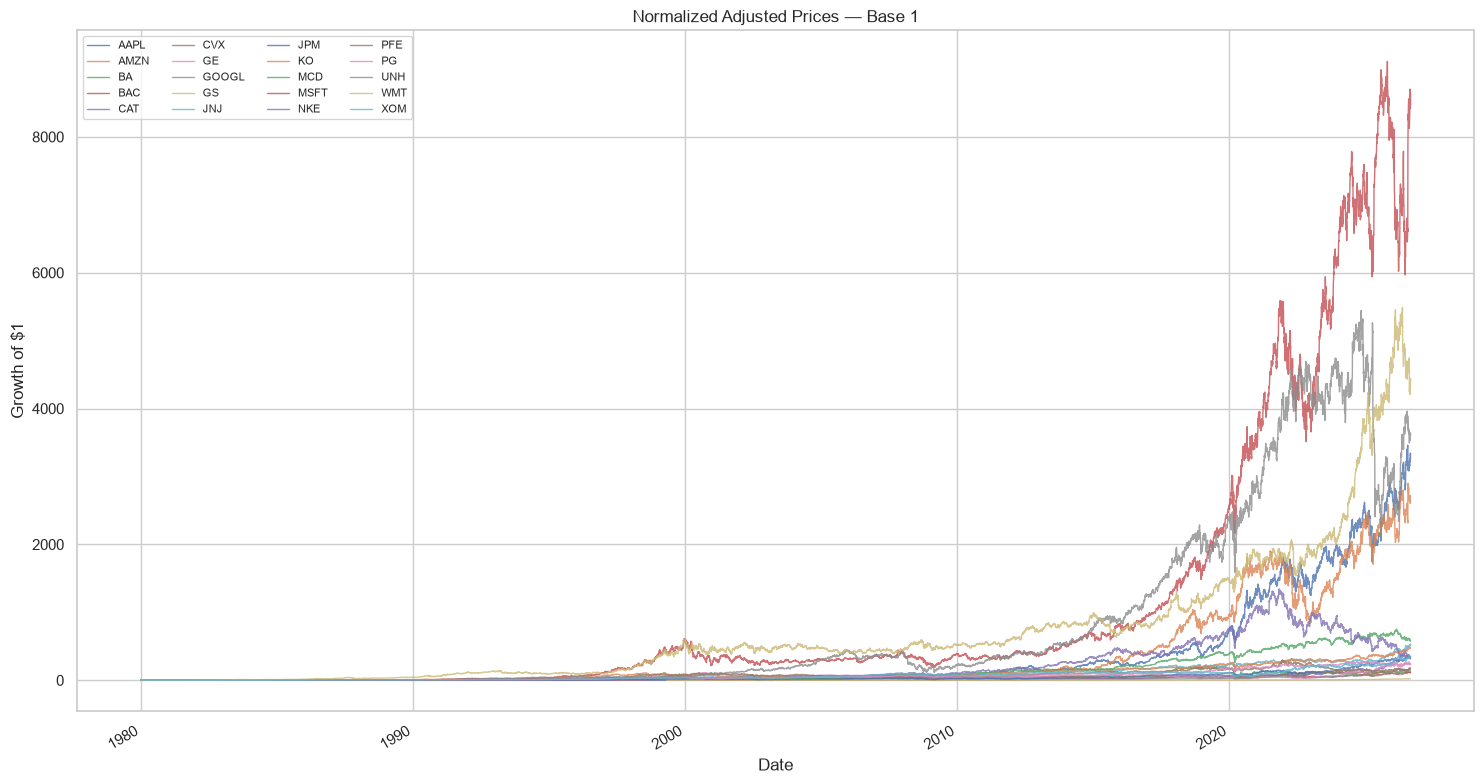

In [29]:
normalized_prices = prices_clean.copy()

for ticker in normalized_prices.columns:
    first_valid_price = normalized_prices[ticker].dropna().iloc[0]

    normalized_prices[ticker] = (
        normalized_prices[ticker] / first_valid_price
    )

normalized_prices.plot(
    figsize=(15, 8),
    linewidth=1,
    alpha=0.80,
)

plt.title("Normalized Adjusted Prices — Base 1")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

In [30]:
prices_clean.to_csv(
    PROCESSED_DIR / "adjusted_close_prices.csv",
    index=True,
)

daily_returns.to_csv(
    PROCESSED_DIR / "daily_returns.csv",
    index=True,
)

quality_report.to_csv(
    PROCESSED_DIR / "data_quality_report.csv",
    index=True,
)

print("Saved files:")
print(PROCESSED_DIR / "adjusted_close_prices.csv")
print(PROCESSED_DIR / "daily_returns.csv")
print(PROCESSED_DIR / "data_quality_report.csv")

Saved files:
data\processed\adjusted_close_prices.csv
data\processed\daily_returns.csv
data\processed\data_quality_report.csv
